# **SETUP**

## *LIBRARIES*

In [7]:
import json
import subprocess
import re
import time
import sys
import pandas as pd
import requests
import gdown
import os
from datetime import datetime
from collections import defaultdict
from pathlib import Path
import numpy as np
from scipy.stats import entropy
from scipy.fft import fft
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.image import imread
from google.colab import files


## *FETCH*

In [2]:
csv_input_dir = "/content/csv-in"
csv_output_dir = "/content/csv-out"

folder_id = '1mZLco7DwN_MmVm-kf78-lYN1XyZdEsJj'

print("Downloading folders from Google Drive...")

gdown.download_folder(
    f'https://drive.google.com/drive/folders/{folder_id}',
    output=csv_input_dir,
    quiet=True,
    use_cookies=False,
    remaining_ok=False
)

print(f"\nContents of {csv_input_dir}:")

for root, dirs, files in os.walk(csv_input_dir):
    level = root.replace(csv_input_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')

removed_count = 0
for root, dirs, files in os.walk(csv_input_dir):
    for f in files:
        if not f.endswith('.csv'):
            file_path = os.path.join(root, f)
            os.remove(file_path)
            removed_count += 1

csv_count = 0
for root, dirs, files in os.walk(csv_input_dir):
    csv_count += len([f for f in files if f.endswith('.csv')])

print(f"\nTotal CSV files downloaded: {csv_count}")


Contents of /content/csv-in:
csv-in/
  window_features_train.csv
  window_features_test.csv
  session_2_16HR/
    xappsdlmalicioso.csv
    xappsdl.csv
    extraction_info.json
  session_1_32HR/
    xappsdlmalicioso.csv
    xappsdl.csv
    extraction_info.json

Total CSV files downloaded: 6


# **DATA PROCESSING**

## *FUNCTIONS*

In [3]:
def preprocess_raw_csv(df):
    df = df.copy()
    df['churn_rate'] = df['keys_affected'] / df['window_duration']
    df['churn_rate'] = df['churn_rate'].fillna(0)
    df['operation_mix_add'] = df['n_adds'] / df['n_total']
    df['operation_mix_remove'] = df['n_removes'] / df['n_total']
    df['operation_mix_update'] = df['n_updates'] / df['n_total']
    df['operation_mix_add'] = df['operation_mix_add'].fillna(0)
    df['operation_mix_remove'] = df['operation_mix_remove'].fillna(0)
    df['operation_mix_update'] = df['operation_mix_update'].fillna(0)
    return df


def calculate_clustering_score(timestamps, window_duration):
    if window_duration <= 0 or len(timestamps) < 2:
        return 0
    min_ts = min(timestamps)
    normalized_ts = [t - min_ts for t in timestamps]
    num_bins = max(int(window_duration), 1)
    bins = np.histogram(normalized_ts, bins=num_bins, range=(0, window_duration))[0]
    mean_ops = np.mean(bins)
    if mean_ops > 0:
        return np.std(bins) / mean_ops
    return 0


def count_bursts(intervals, threshold=0.2):
    if len(intervals) == 0:
        return 0
    in_burst = False
    burst_count = 0
    for interval in intervals:
        if interval < threshold:
            if not in_burst:
                burst_count += 1
                in_burst = True
        else:
            in_burst = False
    return burst_count


def calculate_max_ops_per_second(timestamps, window_duration):
    if len(timestamps) < 2 or window_duration <= 0:
        return 0
    min_ts = min(timestamps)
    normalized_ts = sorted([t - min_ts for t in timestamps])
    max_ops = 0
    for i, ts in enumerate(normalized_ts):
        ops_in_window = sum(1 for t in normalized_ts[i:] if t < ts + 1.0)
        max_ops = max(max_ops, ops_in_window)
    return max_ops


def calculate_spectral_entropy(intervals):
    try:
        if len(intervals) < 4:
            return 0
        fft_vals = np.abs(fft(intervals))
        power = fft_vals ** 2
        power = power / power.sum()
        power = power[power > 0]
        return entropy(power)
    except:
        return 0


def calculate_namespace_stats_from_csv(df):
    namespace_stats = {}
    for namespace in df['namespace'].unique():
        namespace_data = df[df['namespace'] == namespace]['churn_rate']
        if len(namespace_data) > 1:
            namespace_stats[namespace] = {
                'churn_rate_mean': namespace_data.mean(),
                'churn_rate_std': namespace_data.std()
            }
        else:
            namespace_stats[namespace] = {
                'churn_rate_mean': namespace_data.iloc[0] if len(namespace_data) > 0 else 0,
                'churn_rate_std': 1.0
            }
    return namespace_stats


def determine_label(row):
    is_attack_value = row.get('is_attack', 0)
    if pd.isna(is_attack_value):
        return 'benign'
    return 'malicious' if int(is_attack_value) == 1 else 'benign'


def extract_features_from_csv_row(row, namespace_stats):
    namespace = row['namespace']
    features = {

        'namespace': namespace,
        'window_duration': row['window_duration'],
        'n_adds': row['n_adds'],
        'n_removes': row['n_removes'],
        'n_updates': row['n_updates'],
        'n_total': row['n_total'],
        'keys_affected': row['keys_affected'],
        'unique_prefixes': row['unique_prefixes'],

        'churn_rate': row['churn_rate'],
        'operation_mix_add': row['operation_mix_add'],
        'operation_mix_remove': row['operation_mix_remove'],
        'operation_mix_update': row['operation_mix_update'],

        'cross_namespace_ops': row.get('cross_namespace_ops', None),
        'isolation_score': row.get('isolation_score', None),

        'burst_operations': row.get('burst_operations', None),
        'attack_ops': row.get('attack_ops', None),
        'benign_ops': row.get('benign_ops', None),
        'attack_ratio': row.get('attack_ratio', None),
        'is_attack': row.get('is_attack', None),
        'attack_type': row.get('attack_type', None),
    }

    features['operations_per_second'] = (
        row['n_total'] / row['window_duration'] if row['window_duration'] > 0 else 0
    )
    features['update_dominance'] = row['operation_mix_update'] - row['operation_mix_add']

    if namespace in namespace_stats:
        ns_mean = namespace_stats[namespace]['churn_rate_mean']
        ns_std = namespace_stats[namespace]['churn_rate_std']
        features['churn_rate_zscore'] = (
            (row['churn_rate'] - ns_mean) / ns_std if ns_std > 0 else 0
        )
    else:
        features['churn_rate_zscore'] = 0

    timestamps_str = row.get('operation_timestamps', '')
    intervals_str = row.get('inter_op_intervals', '')
    if pd.isna(timestamps_str):
        timestamps_str = ''
    if pd.isna(intervals_str):
        intervals_str = ''

    timestamps = [float(t) for t in str(timestamps_str).split(',') if t] if timestamps_str else []
    intervals = [float(i) for i in str(intervals_str).split(',') if i] if intervals_str else []

    if len(intervals) > 0:
        features['inter_op_mean'] = np.mean(intervals)
        features['inter_op_std'] = np.std(intervals)
        features['inter_op_cv'] = (
            features['inter_op_std'] / features['inter_op_mean']
            if features['inter_op_mean'] > 0 else 0
        )
        features['lag1_autocorr'] = (
            np.corrcoef(intervals[:-1], intervals[1:])[0, 1]
            if len(intervals) > 2 else 0
        )
    else:
        features['inter_op_mean'] = 0
        features['inter_op_std'] = 0
        features['inter_op_cv'] = 0
        features['lag1_autocorr'] = 0

    features['clustering_score'] = (
        calculate_clustering_score(timestamps, row['window_duration'])
        if len(timestamps) > 1 else 0
    )
    features['max_ops_per_second'] = (
        calculate_max_ops_per_second(timestamps, row['window_duration'])
        if len(timestamps) > 1 else 0
    )

    features['burst_count'] = count_bursts(intervals, threshold=0.2) if len(intervals) > 0 else 0
    features['spectral_entropy'] = (
        calculate_spectral_entropy(intervals) if len(intervals) >= 4 else 0
    )

    return features

## *MAIN*

In [4]:
import os

TRAIN_SESSION_NUMBERS = [1]
TEST_SESSION_NUMBERS = [2]
SHUFFLE_DATA = True
RANDOM_SEED = 42

csv_input_dir = "/content/csv-in"
csv_output_dir = "/content/csv-out"
os.makedirs(csv_output_dir, exist_ok=True)


def load_sessions_by_numbers(base_dir, session_numbers, set_name):
    base_path = Path(base_dir)
    all_dfs = []

    print(f"\n=== Loading {set_name} ===")

    for session_num in session_numbers:
        matching_folders = list(base_path.glob(f"session_{session_num}_*HR"))

        if not matching_folders:
            print(f"  WARNING: No folder found for session {session_num}")
            continue

        for folder in matching_folders:
            csv_files = list(folder.glob("*.csv"))

            if not csv_files:
                print(f"  WARNING: No CSV files in {folder.name}")
                continue

            print(f"  {folder.name}: {len(csv_files)} CSV files")

            for csv_file in csv_files:
                try:
                    df = pd.read_csv(csv_file)
                    df = preprocess_raw_csv(df)
                    all_dfs.append(df)
                    print(f"     {csv_file.name}: {len(df)} rows")
                except Exception as e:
                    print(f"     ERROR: {csv_file.name}: {e}")

    if not all_dfs:
        print(f"  ERROR: No data loaded for {set_name}")
        return pd.DataFrame()

    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"  Total: {len(combined_df):,} rows")

    return combined_df


train_df = load_sessions_by_numbers(csv_input_dir, TRAIN_SESSION_NUMBERS, "TRAIN")
test_df = load_sessions_by_numbers(csv_input_dir, TEST_SESSION_NUMBERS, "TEST")

if train_df.empty or test_df.empty:
    raise ValueError("Failed to load data. Check your session folders and numbers.")


if SHUFFLE_DATA:
    print("\n" + "="*70)
    print("SHUFFLING DATA")
    print("="*70)
    print(f"Random seed: {RANDOM_SEED}\n")

    train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"Train data shuffled: {len(train_df)} rows")

    test_df = test_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    print(f"Test data shuffled: {len(test_df)} rows")


print("\n" + "="*70)
print("FEATURE EXTRACTION")
print("="*70)

namespace_stats = calculate_namespace_stats_from_csv(train_df)

print("\nExtracting train features...")
train_features = []
for idx, row in train_df.iterrows():
    if idx % 10000 == 0 and idx > 0:
        print(f"  {idx}/{len(train_df)} rows processed...")
    features = extract_features_from_csv_row(row, namespace_stats)
    features['label'] = determine_label(row)
    train_features.append(features)

train_features_df = pd.DataFrame(train_features)
cols = [col for col in train_features_df.columns if col != 'label'] + ['label']
train_features_df = train_features_df[cols]

train_path = os.path.join(csv_output_dir, "window_features_train.csv")
train_features_df.to_csv(train_path, index=False)
print(f"\nTrain saved: {train_path}")
print(f"  Shape: {train_features_df.shape}")


print("\nExtracting test features...")
test_features = []
for idx, row in test_df.iterrows():
    if idx % 10000 == 0 and idx > 0:
        print(f"  {idx}/{len(test_df)} rows processed...")
    features = extract_features_from_csv_row(row, namespace_stats)
    features['label'] = determine_label(row)
    test_features.append(features)

test_features_df = pd.DataFrame(test_features)
test_features_df = test_features_df[cols]

test_path = os.path.join(csv_output_dir, "window_features_test.csv")
test_features_df.to_csv(test_path, index=False)
print(f"\nTest saved: {test_path}")
print(f"  Shape: {test_features_df.shape}")


for csv_path in [train_path, test_path]:
    with open(csv_path, 'r') as f:
        lines = f.readlines()
    while lines and lines[-1].strip() == '':
        lines.pop()
    with open(csv_path, 'w') as f:
        f.writelines(lines)


print("\n" + "="*70)
print("FINAL STATISTICS")
print("="*70)

total = len(train_features_df) + len(test_features_df)
train_pct = len(train_features_df) / total * 100
test_pct = len(test_features_df) / total * 100

print(f"\nTotal windows: {total:,}")
print(f"  Train: {len(train_features_df):,} ({train_pct:.1f}%) - Sessions: {TRAIN_SESSION_NUMBERS}")
print(f"  Test:  {len(test_features_df):,} ({test_pct:.1f}%) - Sessions: {TEST_SESSION_NUMBERS}")

print(f"\nTrain label distribution:")
print(train_features_df['label'].value_counts())

print(f"\nTest label distribution:")
print(test_features_df['label'].value_counts())

print("\n" + "="*70)
print("COMPLETE")
print("="*70)


=== Loading TRAIN ===
  session_1_32HR: 2 CSV files
     xappsdlmalicioso.csv: 22964 rows
     xappsdl.csv: 22964 rows
  Total: 45,928 rows

=== Loading TEST ===
  session_2_16HR: 2 CSV files
     xappsdlmalicioso.csv: 11483 rows
     xappsdl.csv: 11483 rows
  Total: 22,966 rows

SHUFFLING DATA
Random seed: 42

Train data shuffled: 45928 rows
Test data shuffled: 22966 rows

FEATURE EXTRACTION

Extracting train features...
  10000/45928 rows processed...
  20000/45928 rows processed...
  30000/45928 rows processed...
  40000/45928 rows processed...

Train saved: /content/csv-out/window_features_train.csv
  Shape: (45928, 32)

Extracting test features...
  10000/22966 rows processed...
  20000/22966 rows processed...

Test saved: /content/csv-out/window_features_test.csv
  Shape: (22966, 32)

FINAL STATISTICS

Total windows: 68,894
  Train: 45,928 (66.7%) - Sessions: [1]
  Test:  22,966 (33.3%) - Sessions: [2]

Train label distribution:
label
benign       37595
malicious     8333
Name: 

# **GRAPHS**


All charts saved to: /content/csv-out/plots


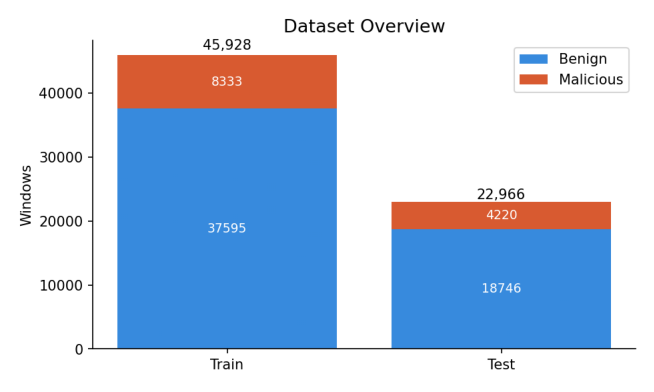

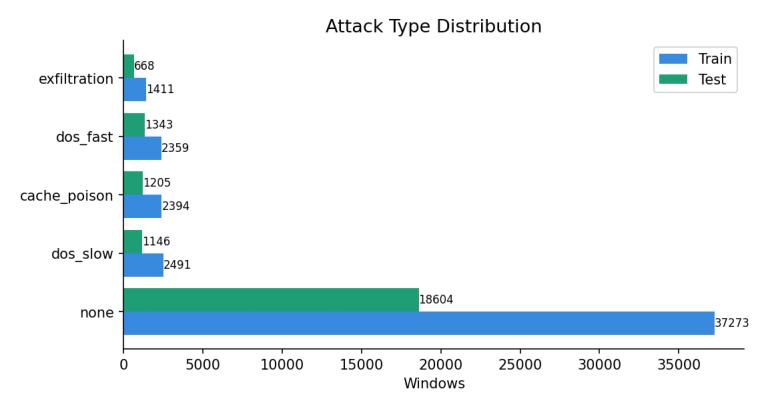

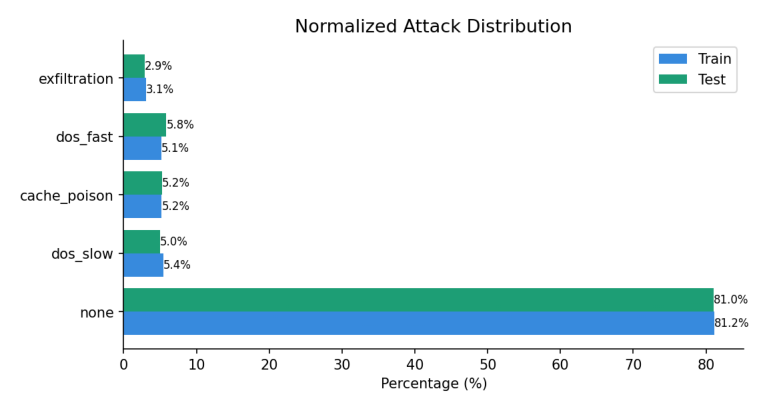

In [5]:

TRAIN_CSV  = "/content/csv-out/window_features_train.csv"
TEST_CSV   = "/content/csv-out/window_features_test.csv"
OUTPUT_DIR = "/content/csv-out/plots"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)

BLUE   = "#378ADD"
ORANGE = "#D85A30"
GREEN  = "#1D9E75"
GRAY   = "#888780"
COLORS = [BLUE, ORANGE, GREEN, "#7F77DD", "#EF9F27", "#D4537E", "#639922"]

def save(fig, name):
    path = f"{OUTPUT_DIR}/{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 4))

labels = ["Train", "Test"]

train_counts = train["label"].value_counts()
test_counts  = test["label"].value_counts()

benign = [train_counts.get("benign", 0), test_counts.get("benign", 0)]
mal    = [train_counts.get("malicious", 0), test_counts.get("malicious", 0)]

x = range(len(labels))

ax.bar(x, benign, label="Benign", color=BLUE)
ax.bar(x, mal, bottom=benign, label="Malicious", color=ORANGE)

for i in range(len(labels)):
    total = benign[i] + mal[i]
    ax.text(i, total + total * 0.02, f"{total:,}", ha="center", fontsize=10)

    if total > 0:
        ax.text(i, benign[i] / 2, f"{benign[i]}", ha="center", va="center", fontsize=9, color="white")
        ax.text(i, benign[i] + mal[i] / 2, f"{mal[i]}", ha="center", va="center", fontsize=9, color="white")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Windows")
ax.set_title("Dataset Overview", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

save(fig, "01_dataset_overview")



if "attack_type" in train.columns:

    train_counts = train["attack_type"].fillna("benign").value_counts()
    test_counts  = test["attack_type"].fillna("benign").value_counts()

    all_labels = sorted(set(train_counts.index).union(test_counts.index))

    all_labels = sorted(all_labels, key=lambda k: train_counts.get(k, 0), reverse=True)

    train_vals = [train_counts.get(k, 0) for k in all_labels]
    test_vals  = [test_counts.get(k, 0) for k in all_labels]

    y = range(len(all_labels))
    height = 0.4

    fig, ax = plt.subplots(figsize=(8, max(4, len(all_labels) * 0.4)))

    ax.barh([i - height/2 for i in y], train_vals, height=height, label="Train", color=BLUE)
    ax.barh([i + height/2 for i in y], test_vals,  height=height, label="Test",  color=GREEN)

    for i, v in enumerate(train_vals):
        ax.text(v, i - height/2, f"{v}", va="center", fontsize=8)

    for i, v in enumerate(test_vals):
        ax.text(v, i + height/2, f"{v}", va="center", fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(all_labels)
    ax.set_xlabel("Windows")
    ax.set_title("Attack Type Distribution", fontsize=13)
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    save(fig, "02_attack_type_comparison")


if "attack_type" in train.columns:

    train_pct = train["attack_type"].fillna("benign").value_counts(normalize=True)
    test_pct  = test["attack_type"].fillna("benign").value_counts(normalize=True)

    all_labels = sorted(set(train_pct.index).union(test_pct.index))
    all_labels = sorted(all_labels, key=lambda k: train_pct.get(k, 0), reverse=True)

    train_vals = [train_pct.get(k, 0) * 100 for k in all_labels]
    test_vals  = [test_pct.get(k, 0) * 100 for k in all_labels]

    y = range(len(all_labels))
    height = 0.4

    fig, ax = plt.subplots(figsize=(8, max(4, len(all_labels) * 0.4)))

    ax.barh([i - height/2 for i in y], train_vals, height=height, label="Train", color=BLUE)
    ax.barh([i + height/2 for i in y], test_vals,  height=height, label="Test",  color=GREEN)

    for i, v in enumerate(train_vals):
        ax.text(v, i - height/2, f"{v:.1f}%", va="center", fontsize=8)

    for i, v in enumerate(test_vals):
        ax.text(v, i + height/2, f"{v:.1f}%", va="center", fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(all_labels)
    ax.set_xlabel("Percentage (%)")
    ax.set_title("Normalized Attack Distribution", fontsize=13)
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    save(fig, "03_attack_type_normalized")


print("\nAll charts saved to:", OUTPUT_DIR)



plot_files = sorted(Path(OUTPUT_DIR).glob("*.png"))
for plot_path in plot_files:
    img = imread(str(plot_path))
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(w / 150, h / 150))
    ax.imshow(img)
    ax.axis("off")
    plt.tight_layout(pad=0)
    plt.show()


# **DOWNLOAD**

In [8]:
files.download(test_path)
files.download(train_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>